In [16]:
from tensorflow import keras
import pandas as pd
from sklearn import datasets
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import numpy as np

In [2]:
data = datasets.load_iris()

In [3]:
df = pd.DataFrame(data.data, columns = data.feature_names)

In [4]:
df["species"] = data.target

In [5]:
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [9]:
df.shape

(150, 5)

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   species            150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 6.0 KB


In [12]:
x = df.drop("species", axis=1)

In [13]:
y = df["species"]

In [14]:
y.value_counts()

species
0    50
1    50
2    50
Name: count, dtype: int64

In [19]:
# divide into training and testing data
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, stratify = y,
                                                    random_state = 14)

In [20]:
# divide training data into training + validation data
x_sub, x_val, y_sub, y_val = train_test_split(x_train, y_train, test_size = 0.2,
                                              stratify = y_train, random_state = 14)

In [21]:
x_sub.shape, x_val.shape, x_test.shape

((96, 4), (24, 4), (30, 4))

In [22]:
# create model
model = keras.Sequential()

In [23]:
# hidden layer
model.add(keras.layers.Dense(16, activation="relu", input_shape=(4,)))

In [24]:
# output layer
model.add(keras.layers.Dense(3, activation="softmax"))

In [25]:
model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 16)                80        
                                                                 
 dense_1 (Dense)             (None, 3)                 51        
                                                                 
Total params: 131 (524.00 Byte)
Trainable params: 131 (524.00 Byte)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [26]:
model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])

In [27]:
# earlystopping callback
es = keras.callbacks.EarlyStopping(patience=8, restore_best_weights=True)

In [28]:
history = model.fit(x_sub, y_sub, validation_data=(x_val, y_val), epochs=100, batch_size=8, callbacks=[es])

Epoch 1/100
12/12 [==============================] - 1s 37ms/step - loss: 1.4940 - accuracy: 0.3333 - val_loss: 1.3406 - val_accuracy: 0.3333
Epoch 2/100
12/12 [==============================] - 0s 8ms/step - loss: 1.2907 - accuracy: 0.4167 - val_loss: 1.1680 - val_accuracy: 0.6667
Epoch 3/100
12/12 [==============================] - 0s 8ms/step - loss: 1.1285 - accuracy: 0.6354 - val_loss: 1.0460 - val_accuracy: 0.6667
Epoch 4/100
12/12 [==============================] - 0s 7ms/step - loss: 1.0175 - accuracy: 0.6562 - val_loss: 0.9594 - val_accuracy: 0.6667
Epoch 5/100
12/12 [==============================] - 0s 7ms/step - loss: 0.9462 - accuracy: 0.6667 - val_loss: 0.8930 - val_accuracy: 0.6667
Epoch 6/100
12/12 [==============================] - 0s 8ms/step - loss: 0.8797 - accuracy: 0.6667 - val_loss: 0.8478 - val_accuracy: 0.6667
Epoch 7/100
12/12 [==============================] - 0s 8ms/step - loss: 0.8395 - accuracy: 0.6562 - val_loss: 0.8128 - val_accuracy: 0.6667
Epoch 8/100


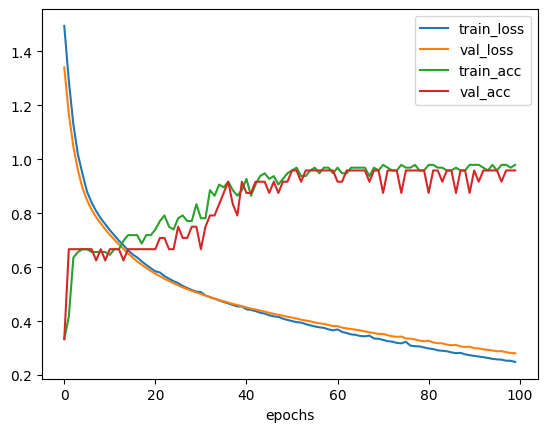

In [29]:
plt.figure()
plt.plot(history.history["loss"], label = "train_loss")
plt.plot(history.history["val_loss"], label = "val_loss")
plt.plot(history.history["accuracy"], label = "train_acc")
plt.plot(history.history["val_accuracy"], label = "val_acc")

plt.xlabel("epochs")
plt.legend()
plt.show()

In [30]:
model.evaluate(x_test, y_test)

1/1 [==============================] - 0s 313ms/step - loss: 0.2638 - accuracy: 0.9667


[0.2638353407382965, 0.9666666388511658]

In [31]:
x_test.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
149,5.9,3.0,5.1,1.8
97,6.2,2.9,4.3,1.3
122,7.7,2.8,6.7,2.0
10,5.4,3.7,1.5,0.2
65,6.7,3.1,4.4,1.4


In [32]:
np.argmax(model.predict(x_test), axis = -1)

1/1 [==============================] - 0s 98ms/step


array([2, 1, 2, 0, 1, 0, 0, 2, 1, 1, 0, 1, 2, 1, 0, 0, 1, 1, 1, 1, 2, 2,
       1, 2, 0, 2, 2, 0, 0, 0])

In [33]:
y_test

149    2
97     1
122    2
10     0
65     1
7      0
42     0
104    2
71     1
61     1
38     0
87     1
131    2
67     1
12     0
22     0
51     1
91     1
133    2
94     1
111    2
143    2
63     1
147    2
24     0
116    2
112    2
16     0
43     0
28     0
Name: species, dtype: int64